# Brightkite Social Network — Big Data Analysis Project (Experiment 2)

## IIT Kharagpur — Big Data Analysis Course

This notebook performs a complete graph-based analysis of the **Brightkite** location-based social network dataset from SNAP.

### Why Brightkite (not Facebook)?
In Experiment 1 (Facebook MUSAE), we found that the **small-world property** caused K=2 neighbourhoods to cover up to 26% of the graph, making all features nearly identical (PC1 = 98.5%). Brightkite is chosen for Experiment 2 because:
- **Average degree = 7.35** (half of Facebook's 15.22)
- **Diameter = 16** (double Facebook's ~8)
- **Clustering = 0.17** (3.5x lower than Facebook's 0.60)
- It is a **location-based** network, so connections are geographic, reducing small-world shortcuts.

### Dataset Stats:
- **58,228 nodes** (Brightkite users)
- **214,078 undirected edges** (mutual friendships)
- Source: [SNAP — loc-Brightkite](https://snap.stanford.edu/data/loc-Brightkite.html)

### Project Steps:
1. Load the Brightkite social media dataset
2. Pick N nodes (N = 58,228 — all nodes)
3. Define undirected links (friendship relationships)
4. Extract K-distance induced neighbourhood subgraphs (K=3, chosen wisely)
5. For each N subgraphs, pick top 20 vertices by degree -> 20-dim dataset
6. PCA analysis — how many PCs capture 90%, 80%, 60% variance

---
## Step 0: Install & Import Dependencies

In [1]:
import sys
!{sys.executable} -m pip install pandas networkx matplotlib scipy scikit-learn seaborn --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scipy
from collections import deque
import random
import time
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
random.seed(42)
np.random.seed(42)

# Plot styling
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
sns.set_style('darkgrid')
print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## Step 1: Load the Brightkite Dataset & Build the Graph

In [3]:
# Load the edge list (tab-separated, no header)
edges_df = pd.read_csv('Brightkite_edges.txt', sep='\t', header=None,
                       names=['id_1', 'id_2'])
print(f'Edge list shape: {edges_df.shape}')
print(f'Columns: {edges_df.columns.tolist()}')
edges_df.head(10)

Edge list shape: (428156, 2)
Columns: ['id_1', 'id_2']


,id_1,id_2
0,0,1
1,0,2
2,0,3
3,0,4
4,0,5
5,0,6
6,0,7
7,0,8
8,0,9
9,0,10


In [4]:
# Build the undirected graph
G = nx.from_pandas_edgelist(edges_df, 'id_1', 'id_2')

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print('=' * 60)
print('       BRIGHTKITE SOCIAL NETWORK STATISTICS')
print('=' * 60)
print(f'  Total Nodes (N):     {num_nodes:,}')
print(f'  Total Edges:         {num_edges:,}')
print(f'  Average Degree:      {2 * num_edges / num_nodes:.2f}')
print(f'  Density:             {nx.density(G):.8f}')
print(f'  Is Connected:        {nx.is_connected(G)}')
if not nx.is_connected(G):
    components = list(nx.connected_components(G))
    largest_cc = max(components, key=len)
    print(f'  Num Components:      {len(components)}')
    print(f'  Largest Component:   {len(largest_cc):,} nodes '
          f'({100*len(largest_cc)/num_nodes:.1f}%)')
    print(f'  --> Using largest connected component for analysis')
    G = G.subgraph(largest_cc).copy()
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    print(f'  Updated Nodes:       {num_nodes:,}')
    print(f'  Updated Edges:       {num_edges:,}')
    print(f'  Updated Avg Degree:  {2 * num_edges / num_nodes:.2f}')
print('=' * 60)

       BRIGHTKITE SOCIAL NETWORK STATISTICS
  Total Nodes (N):     58,228
  Total Edges:         214,078
  Average Degree:      7.35
  Density:             0.00012628
  Is Connected:        False
  Num Components:      547
  Largest Component:   56,739 nodes (97.4%)
  --> Using largest connected component for analysis
  Updated Nodes:       56,739
  Updated Edges:       212,945
  Updated Avg Degree:  7.51


---
## Step 2: Degree Distribution Analysis

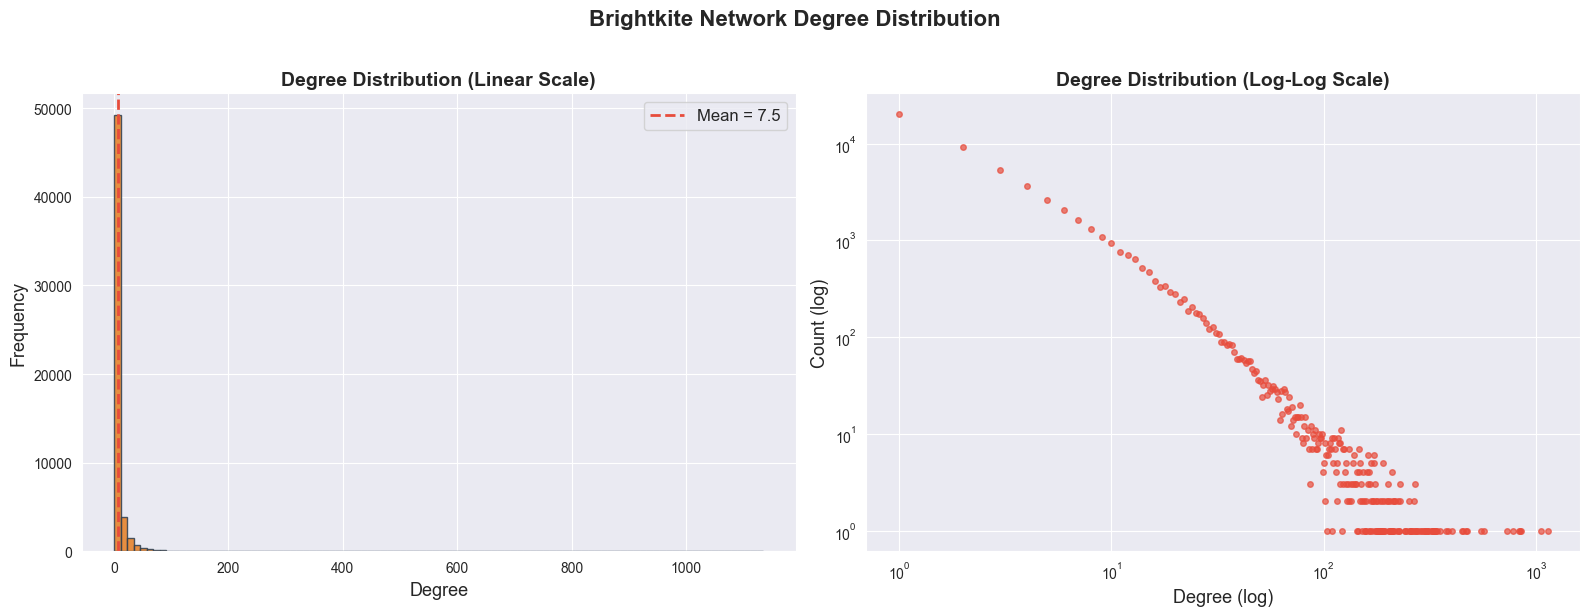

Min degree:    1
Max degree:    1134
Mean degree:   7.51
Median degree: 2
Std deviation: 20.60


In [5]:
degrees = [d for _, d in G.degree()]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(degrees, bins=100, color='#e67e22', edgecolor='#2c3e50', alpha=0.85)
axes[0].set_xlabel('Degree', fontsize=13)
axes[0].set_ylabel('Frequency', fontsize=13)
axes[0].set_title('Degree Distribution (Linear Scale)', fontsize=14, fontweight='bold')
axes[0].axvline(x=np.mean(degrees), color='#e74c3c', linestyle='--', linewidth=2,
                label=f'Mean = {np.mean(degrees):.1f}')
axes[0].legend(fontsize=12)

degree_count = pd.Series(degrees).value_counts().sort_index()
axes[1].loglog(degree_count.index, degree_count.values, 'o',
               color='#e74c3c', markersize=4, alpha=0.7)
axes[1].set_xlabel('Degree (log)', fontsize=13)
axes[1].set_ylabel('Count (log)', fontsize=13)
axes[1].set_title('Degree Distribution (Log-Log Scale)', fontsize=14, fontweight='bold')

plt.suptitle('Brightkite Network Degree Distribution',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Min degree:    {min(degrees)}')
print(f'Max degree:    {max(degrees)}')
print(f'Mean degree:   {np.mean(degrees):.2f}')
print(f'Median degree: {np.median(degrees):.0f}')
print(f'Std deviation: {np.std(degrees):.2f}')

---
## Step 3: Graph Visualization

We visualize:
1. A **sampled subgraph** (1500 nodes via BFS) coloured by Louvain community
2. The **ego network** of the highest-degree hub node
3. Full-network **community structure** overview

Sampled subgraph: 1500 nodes, 11418 edges
Communities detected: 6
Computing layout (spring_layout)...


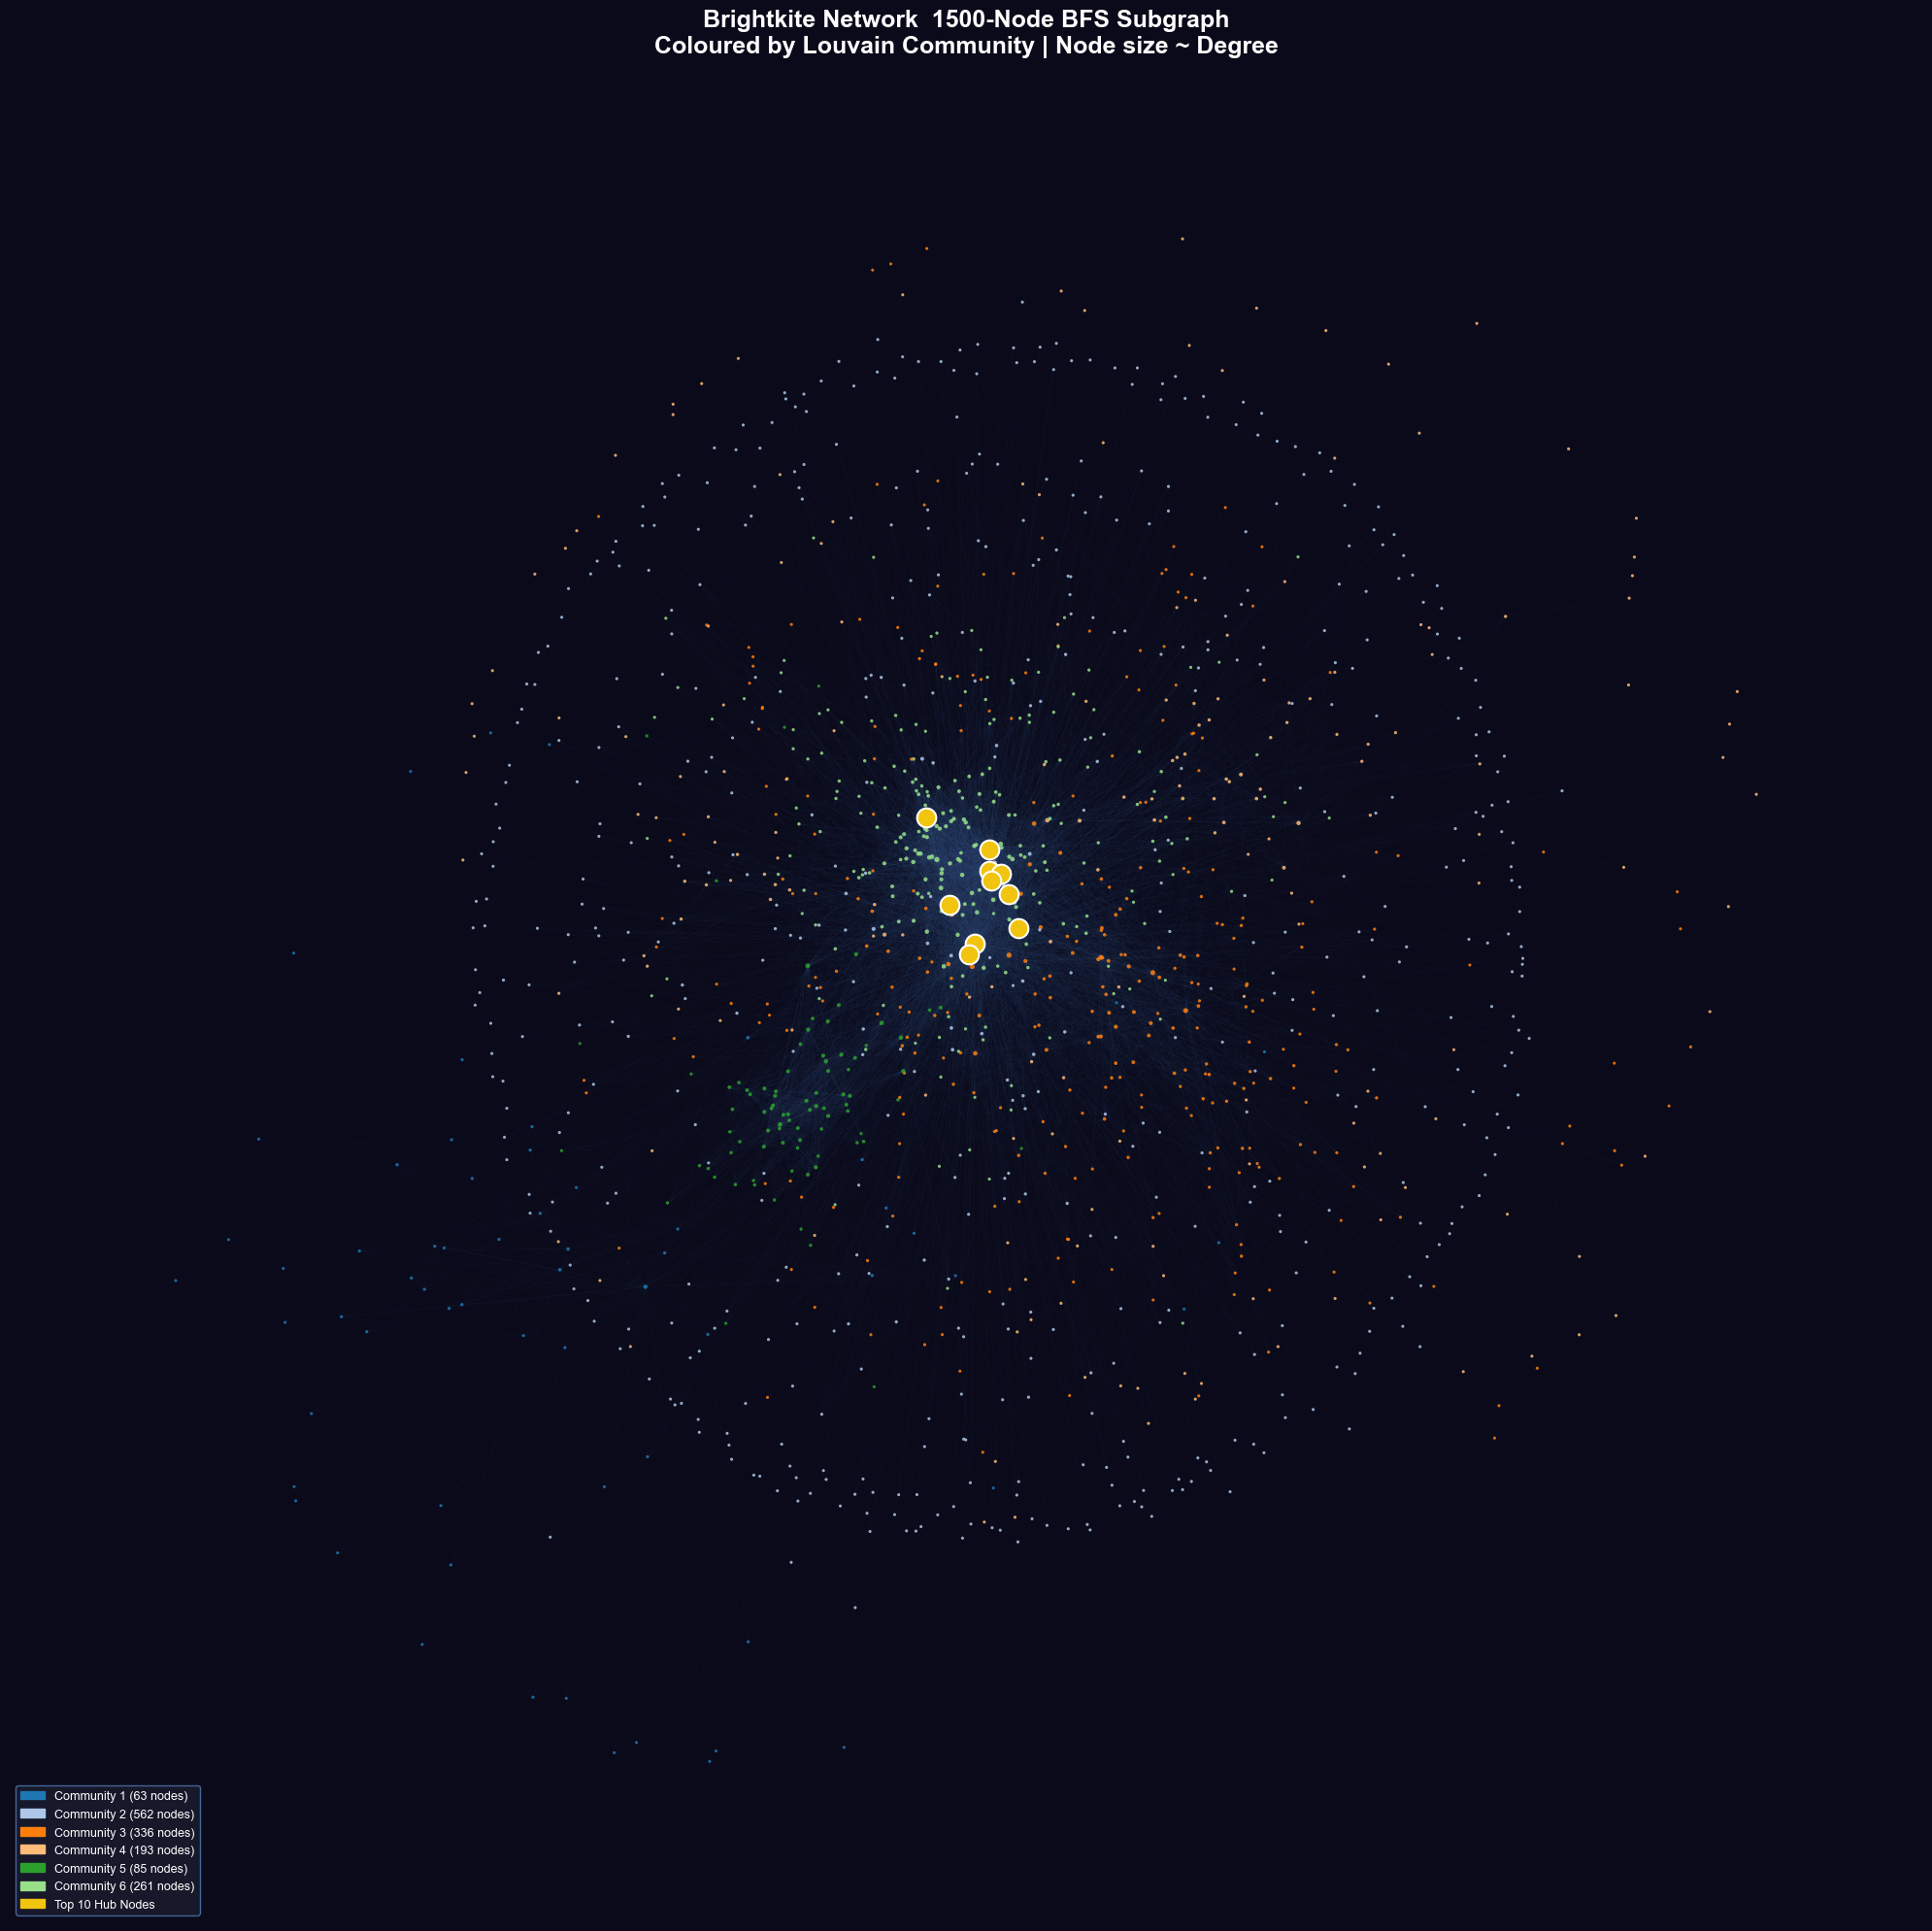

In [6]:
### 3a. Sampled Subgraph — Community-Coloured Visualization ###

start_node = max(G.nodes(), key=lambda n: G.degree(n))
bfs_nodes = []
visited_bfs = {start_node}
queue = deque([start_node])
while queue and len(bfs_nodes) < 1500:
    node = queue.popleft()
    bfs_nodes.append(node)
    for neighbor in G.neighbors(node):
        if neighbor not in visited_bfs:
            visited_bfs.add(neighbor)
            queue.append(neighbor)

G_sub = G.subgraph(bfs_nodes).copy()
print(f'Sampled subgraph: {G_sub.number_of_nodes()} nodes, '
      f'{G_sub.number_of_edges()} edges')

communities = nx.community.louvain_communities(G_sub, seed=42)
print(f'Communities detected: {len(communities)}')

node_community = {}
for idx, comm in enumerate(communities):
    for n in comm:
        node_community[n] = idx

n_comms = len(communities)
palette = plt.cm.tab20(np.linspace(0, 1, max(n_comms, 20)))
node_colors = [palette[node_community[n] % 20] for n in G_sub.nodes()]

sub_degrees = dict(G_sub.degree())
max_deg = max(sub_degrees.values())
node_sizes = [5 + 80 * (sub_degrees[n] / max_deg) for n in G_sub.nodes()]

print('Computing layout (spring_layout)...')
pos = nx.spring_layout(G_sub, k=0.15, iterations=50, seed=42)

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
fig.patch.set_facecolor('#0a0a1a')
ax.set_facecolor('#0a0a1a')

nx.draw_networkx_edges(G_sub, pos, width=0.15, alpha=0.12,
                       edge_color='#4a6fa5', ax=ax)
nx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes,
                       node_color=node_colors, alpha=0.85, ax=ax, linewidths=0)

top10 = sorted(sub_degrees, key=sub_degrees.get, reverse=True)[:10]
nx.draw_networkx_nodes(G_sub, pos, nodelist=top10, node_size=200,
                       node_color='#f1c40f', edgecolors='white',
                       linewidths=1.5, ax=ax)

ax.set_title('Brightkite Network  1500-Node BFS Subgraph\n'
             'Coloured by Louvain Community | Node size ~ Degree',
             fontsize=18, fontweight='bold', color='white', pad=20)
ax.axis('off')

legend_patches = [mpatches.Patch(color=palette[i],
                  label=f'Community {i+1} ({len(communities[i])} nodes)')
                  for i in range(min(10, n_comms))]
legend_patches.append(mpatches.Patch(color='#f1c40f', label='Top 10 Hub Nodes'))
ax.legend(handles=legend_patches, loc='lower left', fontsize=9,
          facecolor='#1a1a2e', edgecolor='#4a6fa5',
          labelcolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

Highest-degree node: 40 (degree = 1134)
Ego network: 3135 nodes, 13628 edges
Computing ego layout...


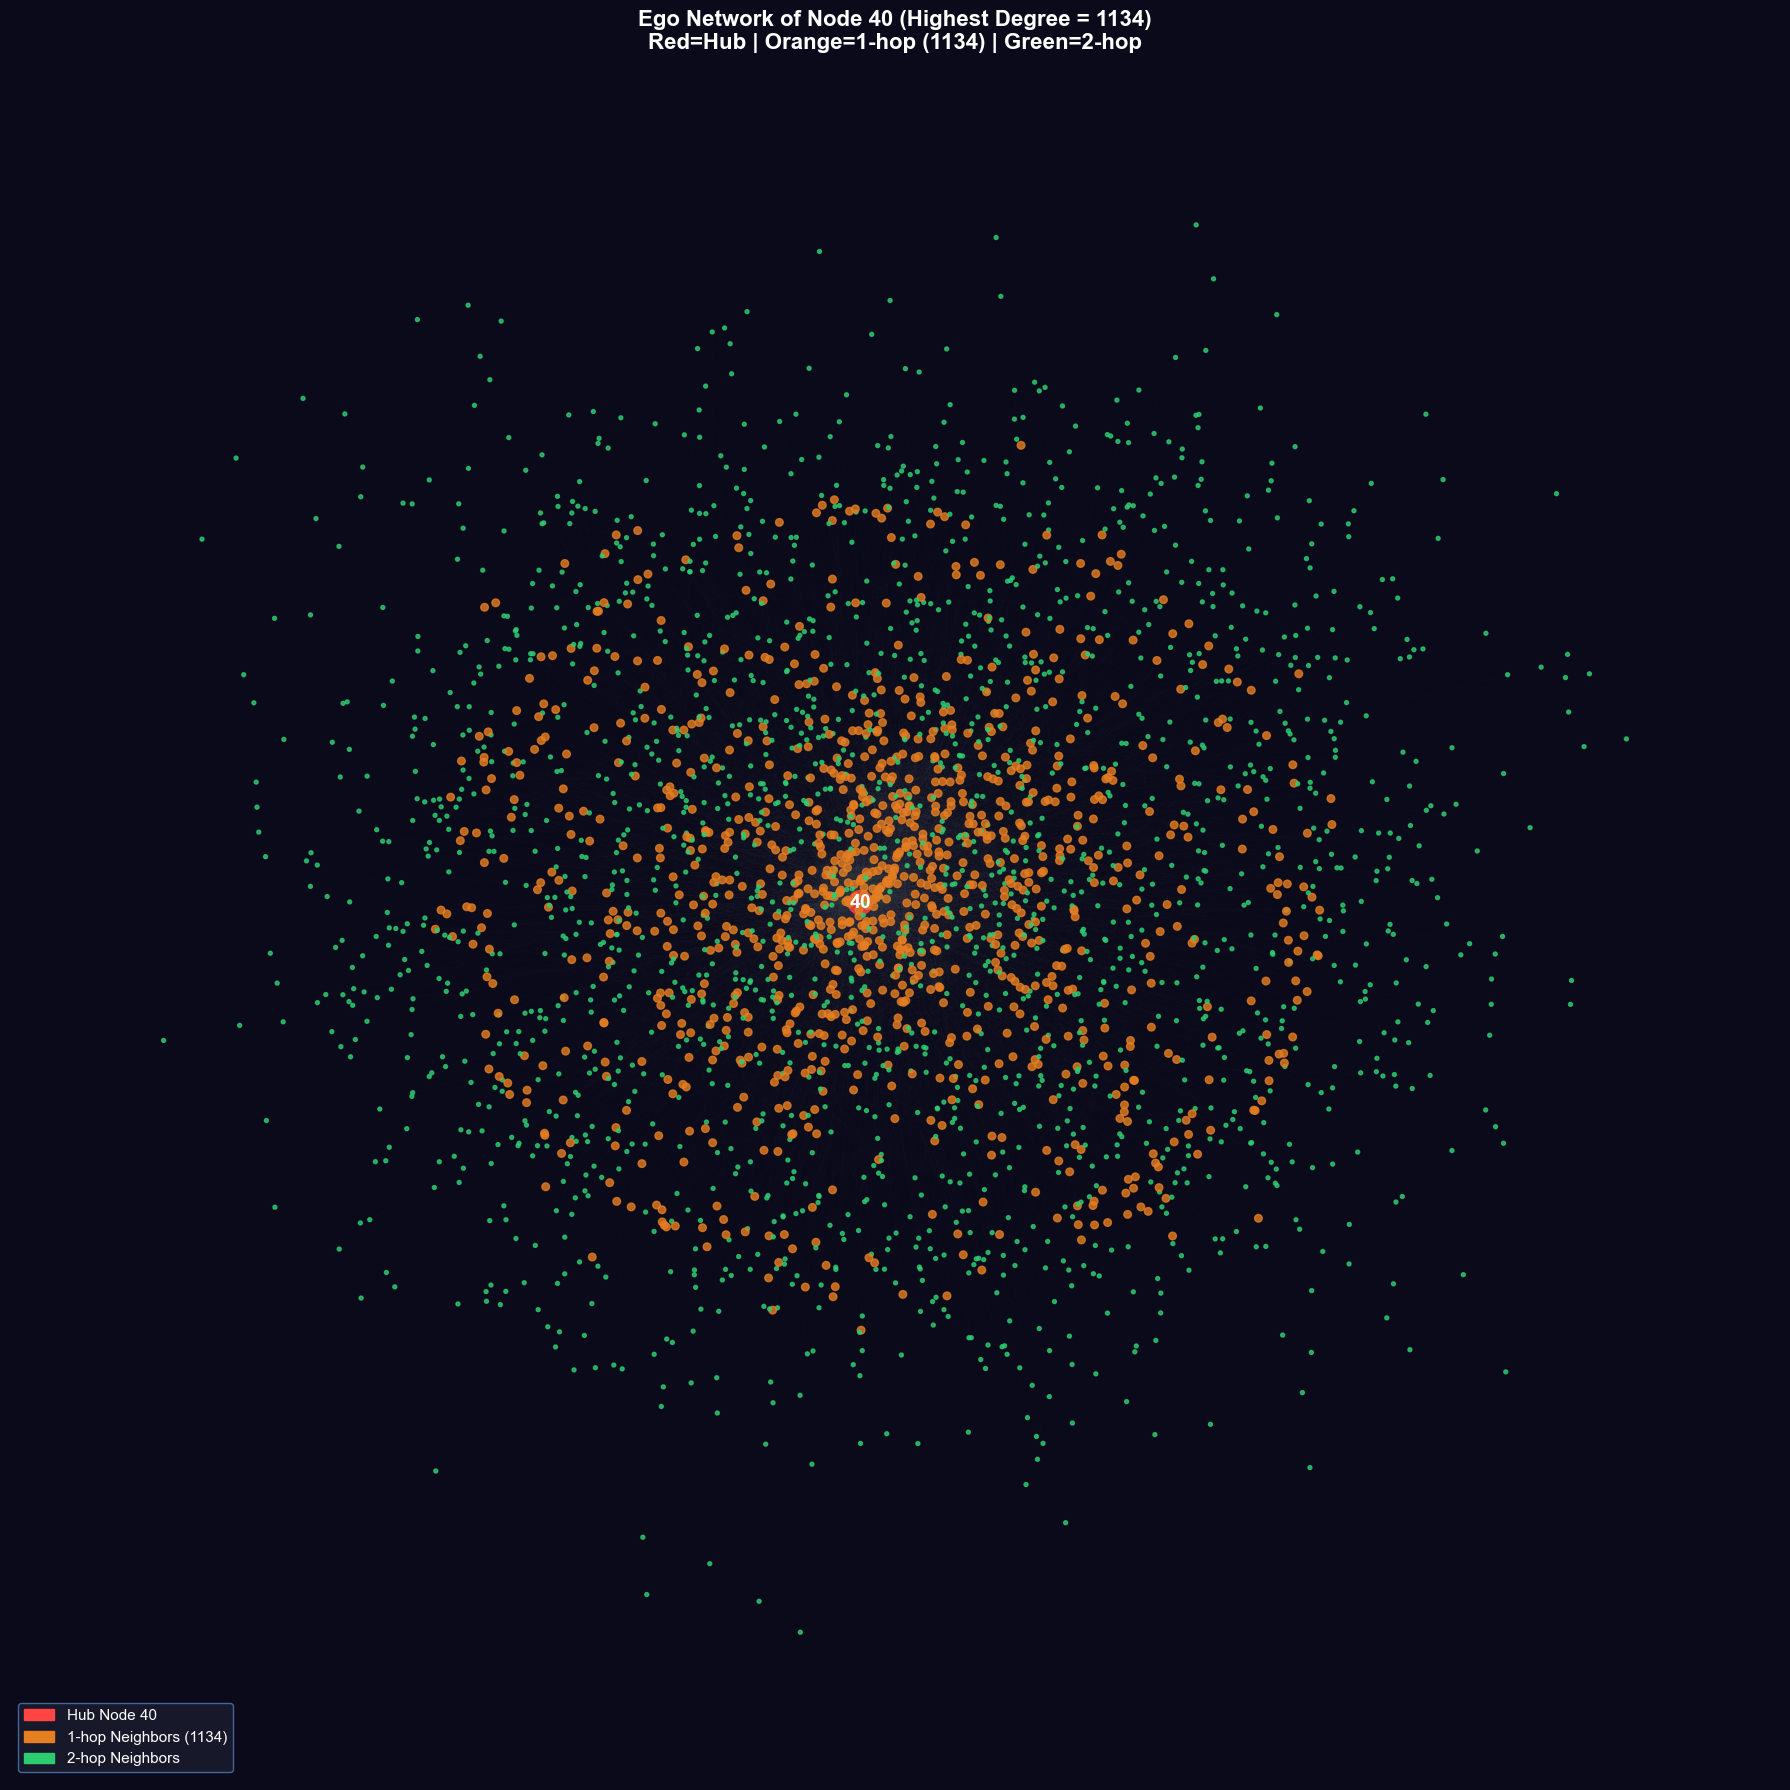

In [7]:
### 3b. Ego Network of the Highest-Degree Node ###

hub_node = max(G.nodes(), key=lambda n: G.degree(n))
print(f'Highest-degree node: {hub_node} (degree = {G.degree(hub_node)})')

ego_graph = nx.ego_graph(G, hub_node, radius=2)

if ego_graph.number_of_nodes() > 3000:
    first_hop = set(G.neighbors(hub_node))
    second_hop = set(ego_graph.nodes()) - first_hop - {hub_node}
    keep_second = set(random.sample(list(second_hop),
                                    min(2000, len(second_hop))))
    keep_nodes = {hub_node} | first_hop | keep_second
    ego_graph = ego_graph.subgraph(keep_nodes).copy()

print(f'Ego network: {ego_graph.number_of_nodes()} nodes, '
      f'{ego_graph.number_of_edges()} edges')

first_hop_set = set(G.neighbors(hub_node))
ego_colors = []
ego_sizes = []
for n in ego_graph.nodes():
    if n == hub_node:
        ego_colors.append('#ff4444'); ego_sizes.append(300)
    elif n in first_hop_set:
        ego_colors.append('#e67e22'); ego_sizes.append(30)
    else:
        ego_colors.append('#2ecc71'); ego_sizes.append(8)

print('Computing ego layout...')
ego_pos = nx.spring_layout(ego_graph, k=0.2, iterations=30, seed=42)

fig, ax = plt.subplots(figsize=(18, 18))
fig.patch.set_facecolor('#0a0a1a')
ax.set_facecolor('#0a0a1a')

nx.draw_networkx_edges(ego_graph, ego_pos, width=0.1, alpha=0.08,
                       edge_color='#7f8c8d', ax=ax)
nx.draw_networkx_nodes(ego_graph, ego_pos, node_size=ego_sizes,
                       node_color=ego_colors, alpha=0.8, ax=ax)
nx.draw_networkx_labels(ego_graph, ego_pos, labels={hub_node: str(hub_node)},
                        font_size=14, font_color='white',
                        font_weight='bold', ax=ax)

ax.set_title(f'Ego Network of Node {hub_node} '
             f'(Highest Degree = {G.degree(hub_node)})\n'
             f'Red=Hub | Orange=1-hop ({len(first_hop_set)}) | Green=2-hop',
             fontsize=16, fontweight='bold', color='white', pad=20)
ax.axis('off')

legend_patches = [
    mpatches.Patch(color='#ff4444', label=f'Hub Node {hub_node}'),
    mpatches.Patch(color='#e67e22',
                   label=f'1-hop Neighbors ({len(first_hop_set)})'),
    mpatches.Patch(color='#2ecc71', label='2-hop Neighbors'),
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=11,
          facecolor='#1a1a2e', edgecolor='#4a6fa5',
          labelcolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

Detecting communities on full graph (Louvain)...
Total communities found: 189
Top 10 community sizes: [9615, 7051, 3589, 3427, 3214, 2804, 1865, 1736, 1544, 1332]


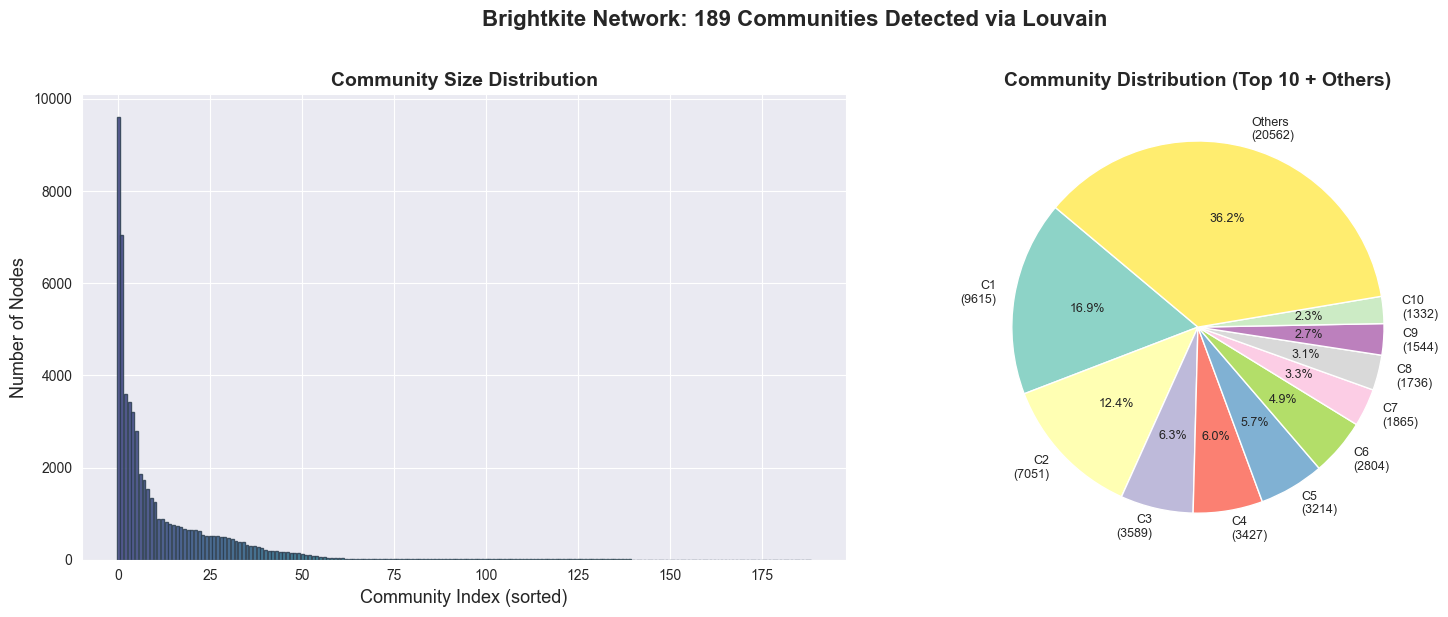

In [8]:
### 3c. Full Network Community Structure ###

print('Detecting communities on full graph (Louvain)...')
full_communities = nx.community.louvain_communities(G, seed=42)
print(f'Total communities found: {len(full_communities)}')

comm_sizes = sorted([len(c) for c in full_communities], reverse=True)
print(f'Top 10 community sizes: {comm_sizes[:10]}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(range(len(comm_sizes)), comm_sizes,
            color=plt.cm.viridis(np.linspace(0.2, 0.9, len(comm_sizes))),
            edgecolor='#2c3e50', alpha=0.85)
axes[0].set_xlabel('Community Index (sorted)', fontsize=13)
axes[0].set_ylabel('Number of Nodes', fontsize=13)
axes[0].set_title('Community Size Distribution', fontsize=14, fontweight='bold')

top_10_sizes = comm_sizes[:10]
other_size = sum(comm_sizes[10:])
pie_sizes = top_10_sizes + [other_size]
pie_labels = ([f'C{i+1}\n({s})' for i, s in enumerate(top_10_sizes)]
              + [f'Others\n({other_size})'])
colors = plt.cm.Set3(np.linspace(0, 1, len(pie_sizes)))
axes[1].pie(pie_sizes, labels=pie_labels, colors=colors,
            autopct='%1.1f%%', startangle=140,
            textprops={'fontsize': 9})
axes[1].set_title('Community Distribution (Top 10 + Others)',
                  fontsize=14, fontweight='bold')

plt.suptitle(f'Brightkite Network: {len(full_communities)} Communities '
             f'Detected via Louvain',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 4: K-Distance Induced Neighbourhood Subgraphs

### Choice of K:
- The professor suggested K=10, but we must **choose wisely** based on the network's structure.
- We first verify neighbourhood sizes at K=1,2,3,4,5 on a sample of nodes.
- Then choose the K that gives **meaningful, differentiated** subgraphs.

In [9]:
# Verify: Neighbourhood sizes at different K values (sample 30 nodes)
sample_check = random.sample(list(G.nodes()), 30)
k_values = [1, 2, 3, 4, 5]

print(f'{"Node":>8}', end='')
for k in k_values:
    print(f'  {"K="+str(k):>8}', end='')
print()
print('-' * (8 + 10 * len(k_values)))

k_sizes = {k: [] for k in k_values}

for node in sample_check:
    print(f'{node:>8}', end='')
    for k in k_values:
        ego = nx.ego_graph(G, node, radius=k)
        s = ego.number_of_nodes()
        k_sizes[k].append(s)
        print(f'  {s:>8}', end='')
    print()

print(f'\n{"MEAN":>8}', end='')
for k in k_values:
    print(f'  {np.mean(k_sizes[k]):>8.0f}', end='')
print(f'\n{"MAX":>8}', end='')
for k in k_values:
    print(f'  {np.max(k_sizes[k]):>8}', end='')
print(f'\n{"% graph":>8}', end='')
for k in k_values:
    print(f'  {100*np.mean(k_sizes[k])/num_nodes:>7.1f}%', end='')

print(f'\n\nTotal nodes in graph: {num_nodes:,}')
print('\nConclusion: K=3 gives neighbourhoods of ~100-1000 nodes (< 2% of graph).')
print('This is ideal: large enough for 20 features, small enough for diversity.')

    Node       K=1       K=2       K=3       K=4       K=5
----------------------------------------------------------
    6157         7       373      8114     34572     51983
   44030         2         4         6        25       432
    5775         4       961     15969     43984     54240
    6286        31      1605     17119     43802     54249
   30218         2        10      1892     16618     43151
    6505         8      1097     14314     41146     53683
   49880         2        14       216      6678     35638
   35761         2         5        40      1022     16107
   26033         2        90      4089     29394     50170
   54226         3         5        15       402      9080
    9057         5       755     15531     43417     54162
   38100         3        26      1283     19479     45981
    4119        14      1726     15856     43021     54114
   39951         2       207      2876     18496     44996
   38424         3       134      2547     17761     442

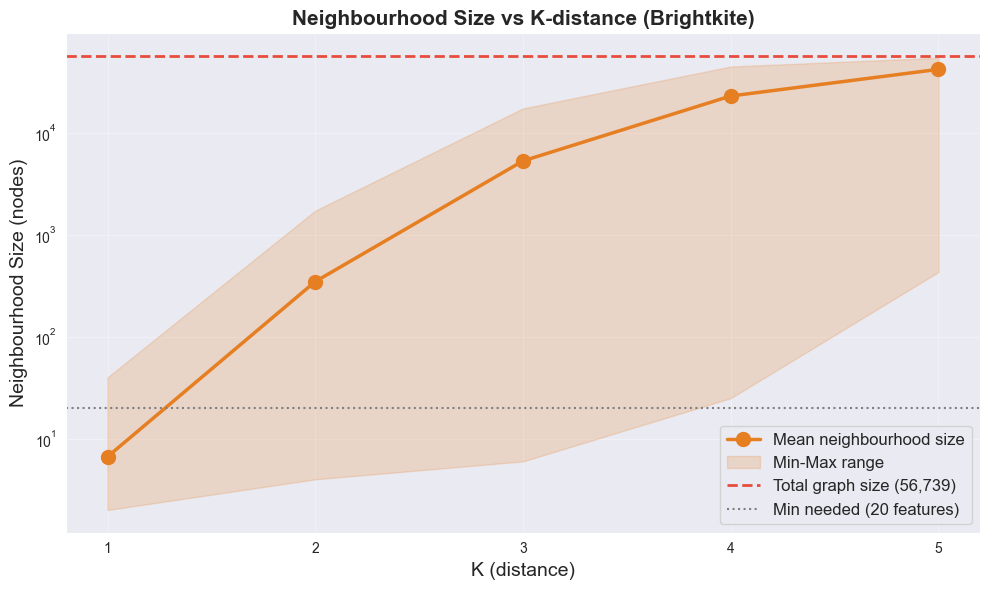

K=3 chosen: neighbourhoods are large enough for 20 features
but small enough to be diverse across different nodes.


In [11]:
# Visualize K vs neighbourhood size
fig, ax = plt.subplots(figsize=(10, 6))

means = [np.mean(k_sizes[k]) for k in k_values]
maxes = [np.max(k_sizes[k]) for k in k_values]
mins = [np.min(k_sizes[k]) for k in k_values]

ax.plot(k_values, means, 'o-', color='#e67e22', linewidth=2.5,
        markersize=10, label='Mean neighbourhood size')
ax.fill_between(k_values, mins, maxes, alpha=0.2, color='#e67e22',
                label='Min-Max range')
ax.axhline(y=num_nodes, color='#e74c3c', linestyle='--', linewidth=2,
           label=f'Total graph size ({num_nodes:,})')
ax.axhline(y=20, color='gray', linestyle=':', linewidth=1.5,
           label='Min needed (20 features)')

ax.set_xlabel('K (distance)', fontsize=14)
ax.set_ylabel('Neighbourhood Size (nodes)', fontsize=14)
ax.set_title('Neighbourhood Size vs K-distance (Brightkite)',
             fontsize=15, fontweight='bold')
ax.set_yscale('log')
ax.set_xticks(k_values)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('K=3 chosen: neighbourhoods are large enough for 20 features')
print('but small enough to be diverse across different nodes.')

In [13]:
# Extract K=3 neighbourhood subgraphs for ALL N nodes
K = 3
N = G.number_of_nodes()
all_nodes = list(G.nodes())

print(f'Extracting {K}-distance neighbourhood subgraphs for all {N:,} nodes...')
print(f'This will take several minutes. Progress updates every 2000 nodes:\n')

t_start = time.time()

# Pre-compute adjacency sets for fast lookups
adj = {n: set(G.neighbors(n)) for n in G.nodes()}
print(f'Adjacency pre-computed in {time.time()-t_start:.1f}s')

feature_matrix = []      # N x 20
neighbourhood_sizes = [] # track subgraph sizes

for i, node in enumerate(all_nodes):
    # BFS to depth K=3
    # Level 0: node itself
    # Level 1: direct neighbors
    # Level 2: neighbors-of-neighbors
    # Level 3: 3rd hop
    level1 = adj[node]
    visited = {node} | level1
    
    # Level 2
    level2_new = set()
    for v in level1:
        level2_new.update(adj[v])
    level2_new -= visited
    visited.update(level2_new)
    
    # Level 3
    level3_new = set()
    for v in level2_new:
        level3_new.update(adj[v])
    level3_new -= visited
    visited.update(level3_new)

    neighbourhood_sizes.append(len(visited))

    # Compute degrees within the induced subgraph
    deg_list = [len(adj[v] & visited) for v in visited]

    # Sort descending, take top 20
    deg_list.sort(reverse=True)
    top20 = deg_list[:20]
    if len(top20) < 20:
        top20 += [0] * (20 - len(top20))

    feature_matrix.append(top20)

    # Progress
    if (i + 1) % 2000 == 0 or (i + 1) == N:
        elapsed = time.time() - t_start
        rate = (i + 1) / elapsed if elapsed > 0 else 0
        eta = (N - i - 1) / rate if rate > 0 else 0
        print(f'  [{i+1:>6}/{N}] {100*(i+1)/N:5.1f}% '
              f'| elapsed: {elapsed:7.1f}s '
              f'| ETA: {eta:7.1f}s '
              f'| nbhd size: {len(visited)}')

t_total = time.time() - t_start
print(f'\nDone! Total time: {t_total:.1f} seconds')
print(f'Feature matrix shape: ({len(feature_matrix)}, {len(feature_matrix[0])})')

Extracting 3-distance neighbourhood subgraphs for all 56,739 nodes...
This will take several minutes. Progress updates every 2000 nodes:

Adjacency pre-computed in 0.3s
  [  2000/56739]   3.5% | elapsed:   121.4s | ETA:  3321.8s | nbhd size: 30686
  [  4000/56739]   7.0% | elapsed:   271.4s | ETA:  3578.7s | nbhd size: 13733
  [  6000/56739]  10.6% | elapsed:   372.7s | ETA:  3151.5s | nbhd size: 4550
  [  8000/56739]  14.1% | elapsed:   469.6s | ETA:  2861.1s | nbhd size: 8208
  [ 10000/56739]  17.6% | elapsed:   548.6s | ETA:  2563.9s | nbhd size: 8217
  [ 12000/56739]  21.1% | elapsed:   595.6s | ETA:  2220.6s | nbhd size: 491
  [ 14000/56739]  24.7% | elapsed:   621.4s | ETA:  1897.0s | nbhd size: 6364
  [ 16000/56739]  28.2% | elapsed:   645.6s | ETA:  1643.7s | nbhd size: 4759
  [ 18000/56739]  31.7% | elapsed:   670.2s | ETA:  1442.3s | nbhd size: 5491
  [ 20000/56739]  35.2% | elapsed:   689.9s | ETA:  1267.4s | nbhd size: 2957
  [ 22000/56739]  38.8% | elapsed:   710.1s | ETA:

---
## Step 5: Build the 20-Dimensional Dataset

Each row = one node. The 20 columns = degrees of the top-20 highest-degree vertices in that node's K-neighbourhood induced subgraph.

In [14]:
# Convert to DataFrame
feature_columns = [f'Top_Degree_{i+1}' for i in range(20)]
df_features = pd.DataFrame(feature_matrix, columns=feature_columns,
                           index=all_nodes)
df_features.index.name = 'Node_ID'

print('20-Dimensional Feature Dataset:')
print(f'Shape: {df_features.shape}\n')
df_features.head(10)

20-Dimensional Feature Dataset:
Shape: (56739, 20)



,Top_Degree_1,Top_Degree_2,Top_Degree_3,Top_Degree_4,Top_Degree_5,Top_Degree_6,Top_Degree_7,Top_Degree_8,Top_Degree_9,Top_Degree_10,Top_Degree_11,Top_Degree_12,Top_Degree_13,Top_Degree_14,Top_Degree_15,Top_Degree_16,Top_Degree_17,Top_Degree_18,Top_Degree_19,Top_Degree_20
Node_ID,,,,,,,,,,,,,,,,,,,,
0,1134,1055,854,838,833,779,732,569,550,475,467,453,448,404,386,379,354,343,337,334
1,1134,1055,854,838,833,779,732,569,550,475,467,453,448,404,386,354,343,337,334,333
2,1134,1055,854,838,833,779,732,569,550,475,467,453,448,404,386,379,354,343,337,334
3,1134,1055,854,838,833,779,732,569,550,475,467,453,448,404,386,379,354,343,337,334
4,1134,1055,854,838,833,779,732,569,475,467,453,448,386,369,354,343,337,334,332,327
5,1134,1055,854,838,833,779,732,569,550,475,467,453,448,404,373,354,343,337,334,333
6,1134,1055,854,838,833,779,732,569,550,475,467,453,448,404,386,379,354,343,337,334
7,1134,1055,854,838,833,779,732,569,550,475,467,453,448,404,386,379,354,343,337,334
8,1134,854,838,779,569,467,425,401,368,332,326,306,259,254,250,240,230,214,209,207


In [15]:
# Summary statistics
print('Feature Statistics:')
df_features.describe().round(2)

Feature Statistics:


,Top_Degree_1,Top_Degree_2,Top_Degree_3,Top_Degree_4,Top_Degree_5,Top_Degree_6,Top_Degree_7,Top_Degree_8,Top_Degree_9,Top_Degree_10,Top_Degree_11,Top_Degree_12,Top_Degree_13,Top_Degree_14,Top_Degree_15,Top_Degree_16,Top_Degree_17,Top_Degree_18,Top_Degree_19,Top_Degree_20
count,56739.00,56739.00,56739.00,56739.00,56739.00,56739.00,56739.00,56739.00,56739.00,56739.00,56739.00,56739.00,56739.00,56739.00,56739.00,56739.00,56739.00,56739.00,56739.00,56739.00
mean,644.76,457.15,373.30,326.71,295.60,268.85,246.65,222.00,204.34,192.21,183.70,174.17,166.28,159.29,153.79,149.08,144.75,141.10,137.68,134.60
std,447.83,371.42,316.21,286.93,263.36,237.91,214.93,183.86,165.30,153.87,147.25,138.45,131.53,125.05,120.79,117.30,114.18,111.72,109.49,107.45
min,2.00,2.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,163.00,91.00,73.00,64.00,57.00,53.00,49.00,46.00,44.00,42.00,41.00,39.00,38.00,37.00,35.00,35.00,33.00,32.00,31.00,30.00
50%,833.00,339.00,296.00,258.00,230.00,213.00,202.00,191.00,183.00,173.00,166.00,159.00,153.00,147.00,141.00,135.00,129.00,126.00,122.00,119.00
75%,1134.00,838.00,732.00,514.00,467.00,439.00,387.00,354.00,333.00,325.00,310.00,296.00,281.00,270.00,262.00,253.00,245.00,236.00,228.00,225.00
max,1134.00,1055.00,854.00,838.00,833.00,779.00,732.00,569.00,550.00,475.00,467.00,453.00,448.00,404.00,386.00,379.00,354.00,343.00,337.00,334.00


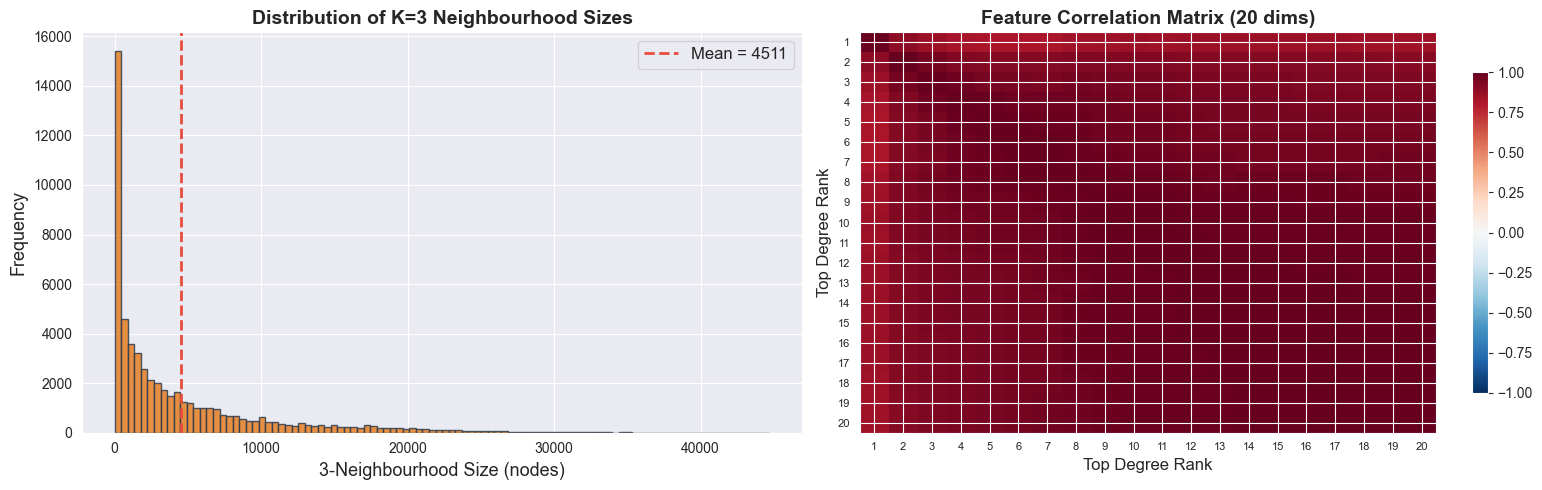

Neighbourhood size stats:
  Min:    4
  Max:    44694
  Mean:   4511
  Median: 2064


In [16]:
# Neighbourhood size distribution + Feature correlation matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(neighbourhood_sizes, bins=100, color='#e67e22',
             edgecolor='#2c3e50', alpha=0.85)
axes[0].set_xlabel(f'{K}-Neighbourhood Size (nodes)', fontsize=13)
axes[0].set_ylabel('Frequency', fontsize=13)
axes[0].set_title(f'Distribution of K={K} Neighbourhood Sizes',
                  fontsize=14, fontweight='bold')
axes[0].axvline(x=np.mean(neighbourhood_sizes), color='#e74c3c',
                linestyle='--', linewidth=2,
                label=f'Mean = {np.mean(neighbourhood_sizes):.0f}')
axes[0].legend(fontsize=12)

# Heatmap
corr = df_features.corr()
im = axes[1].imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[1].set_xticks(range(20))
axes[1].set_yticks(range(20))
axes[1].set_xticklabels([str(i+1) for i in range(20)], fontsize=8)
axes[1].set_yticklabels([str(i+1) for i in range(20)], fontsize=8)
axes[1].set_title('Feature Correlation Matrix (20 dims)',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Top Degree Rank', fontsize=12)
axes[1].set_ylabel('Top Degree Rank', fontsize=12)
plt.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

print(f'Neighbourhood size stats:')
print(f'  Min:    {min(neighbourhood_sizes)}')
print(f'  Max:    {max(neighbourhood_sizes)}')
print(f'  Mean:   {np.mean(neighbourhood_sizes):.0f}')
print(f'  Median: {np.median(neighbourhood_sizes):.0f}')

---
## Step 6: Principal Component Analysis (PCA)

We apply PCA to the 20-dimensional dataset to determine how many principal components are needed to capture:
- **90%** of total variance
- **80%** of total variance
- **60%** of total variance

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.values)

print(f'Scaled data shape: {X_scaled.shape}')
print(f'Mean (should be ~0): {X_scaled.mean(axis=0)[:5].round(6)}')
print(f'Std  (should be ~1): {X_scaled.std(axis=0)[:5].round(6)}')

Scaled data shape: (56739, 20)
Mean (should be ~0): [0. 0. 0. 0. 0.]
Std  (should be ~1): [1. 1. 1. 1. 1.]


In [18]:
# Run PCA with all 20 components
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print('=' * 65)
print('             PCA  EXPLAINED VARIANCE ANALYSIS')
print('=' * 65)
print(f'{"PC":>4}  {"Individual %":>15}  {"Cumulative %":>15}')
print('-' * 65)
for i in range(20):
    bar = '#' * int(explained_var[i] * 100)
    print(f'PC{i+1:>2}  {explained_var[i]*100:>14.2f}%  '
          f'{cumulative_var[i]*100:>14.2f}%  {bar}')
print('=' * 65)

             PCA  EXPLAINED VARIANCE ANALYSIS
  PC     Individual %     Cumulative %
-----------------------------------------------------------------
PC 1           95.93%           95.93%  ###############################################################################################
PC 2            1.56%           97.49%  #
PC 3            1.33%           98.82%  #
PC 4            0.40%           99.22%  
PC 5            0.23%           99.45%  
PC 6            0.15%           99.60%  
PC 7            0.11%           99.70%  
PC 8            0.07%           99.78%  
PC 9            0.05%           99.83%  
PC10            0.04%           99.88%  
PC11            0.03%           99.90%  
PC12            0.03%           99.93%  
PC13            0.02%           99.96%  
PC14            0.01%           99.97%  
PC15            0.01%           99.98%  
PC16            0.01%           99.99%  
PC17            0.01%           99.99%  
PC18            0.00%          100.00%  
PC19          

In [19]:
# Determine PCs needed for 60%, 80%, 90% variance
thresholds = [0.60, 0.80, 0.90]
results = {}

print('=' * 55)
print('    PCs REQUIRED TO CAPTURE VARIANCE THRESHOLDS')
print('=' * 55)

for threshold in thresholds:
    n_pcs = int(np.argmax(cumulative_var >= threshold)) + 1
    actual_var = cumulative_var[n_pcs - 1]
    results[threshold] = n_pcs
    print(f'  {threshold*100:.0f}% variance  -->  '
          f'{n_pcs:>2} PCs needed  (actual: {actual_var*100:.2f}%)')

print('=' * 55)

    PCs REQUIRED TO CAPTURE VARIANCE THRESHOLDS
  60% variance  -->   1 PCs needed  (actual: 95.93%)
  80% variance  -->   1 PCs needed  (actual: 95.93%)
  90% variance  -->   1 PCs needed  (actual: 95.93%)


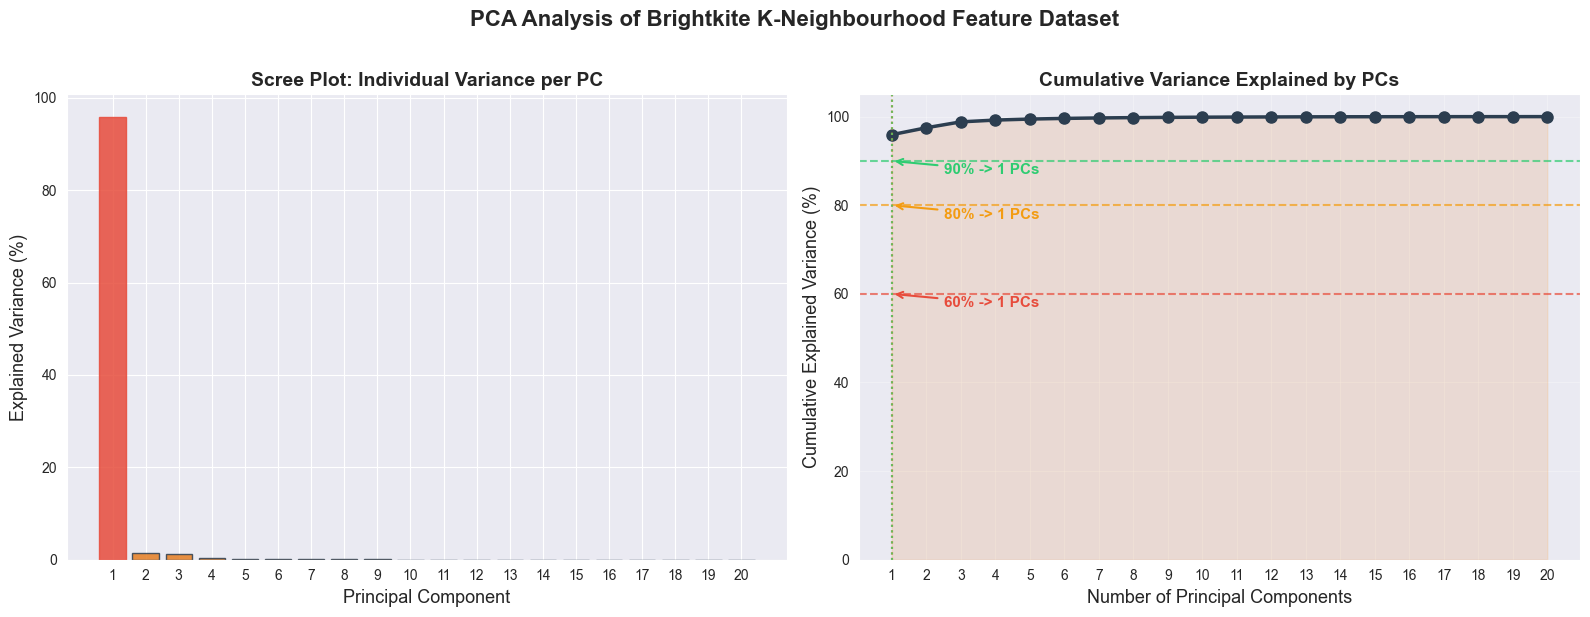

In [20]:
# Visualization: Scree plot + Cumulative variance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pc_indices = range(1, 21)

# Scree plot
bars = axes[0].bar(pc_indices, explained_var * 100,
                   color='#e67e22', edgecolor='#2c3e50', alpha=0.85)
axes[0].set_xlabel('Principal Component', fontsize=13)
axes[0].set_ylabel('Explained Variance (%)', fontsize=13)
axes[0].set_title('Scree Plot: Individual Variance per PC',
                  fontsize=14, fontweight='bold')
axes[0].set_xticks(pc_indices)

# Colour bars by threshold
for i, bar in enumerate(bars):
    if i < results[0.60]:
        bar.set_color('#e74c3c')
    elif i < results[0.80]:
        bar.set_color('#f39c12')
    elif i < results[0.90]:
        bar.set_color('#2ecc71')

# Cumulative plot
axes[1].plot(pc_indices, cumulative_var * 100, 'o-',
             color='#2c3e50', linewidth=2.5, markersize=8)
axes[1].fill_between(pc_indices, 0, cumulative_var * 100,
                     alpha=0.15, color='#e67e22')

colors_t = {0.60: '#e74c3c', 0.80: '#f39c12', 0.90: '#2ecc71'}
for thr in thresholds:
    n_pcs = results[thr]
    c = colors_t[thr]
    axes[1].axhline(y=thr*100, color=c, linestyle='--', alpha=0.7)
    axes[1].axvline(x=n_pcs, color=c, linestyle=':', alpha=0.7)
    axes[1].annotate(f'{thr*100:.0f}% -> {n_pcs} PCs',
                     xy=(n_pcs, thr*100),
                     xytext=(n_pcs + 1.5, thr*100 - 3),
                     fontsize=11, fontweight='bold', color=c,
                     arrowprops=dict(arrowstyle='->', color=c, lw=1.5))

axes[1].set_xlabel('Number of Principal Components', fontsize=13)
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontsize=13)
axes[1].set_title('Cumulative Variance Explained by PCs',
                  fontsize=14, fontweight='bold')
axes[1].set_xticks(pc_indices)
axes[1].set_ylim(0, 105)
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA Analysis of Brightkite K-Neighbourhood Feature Dataset',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

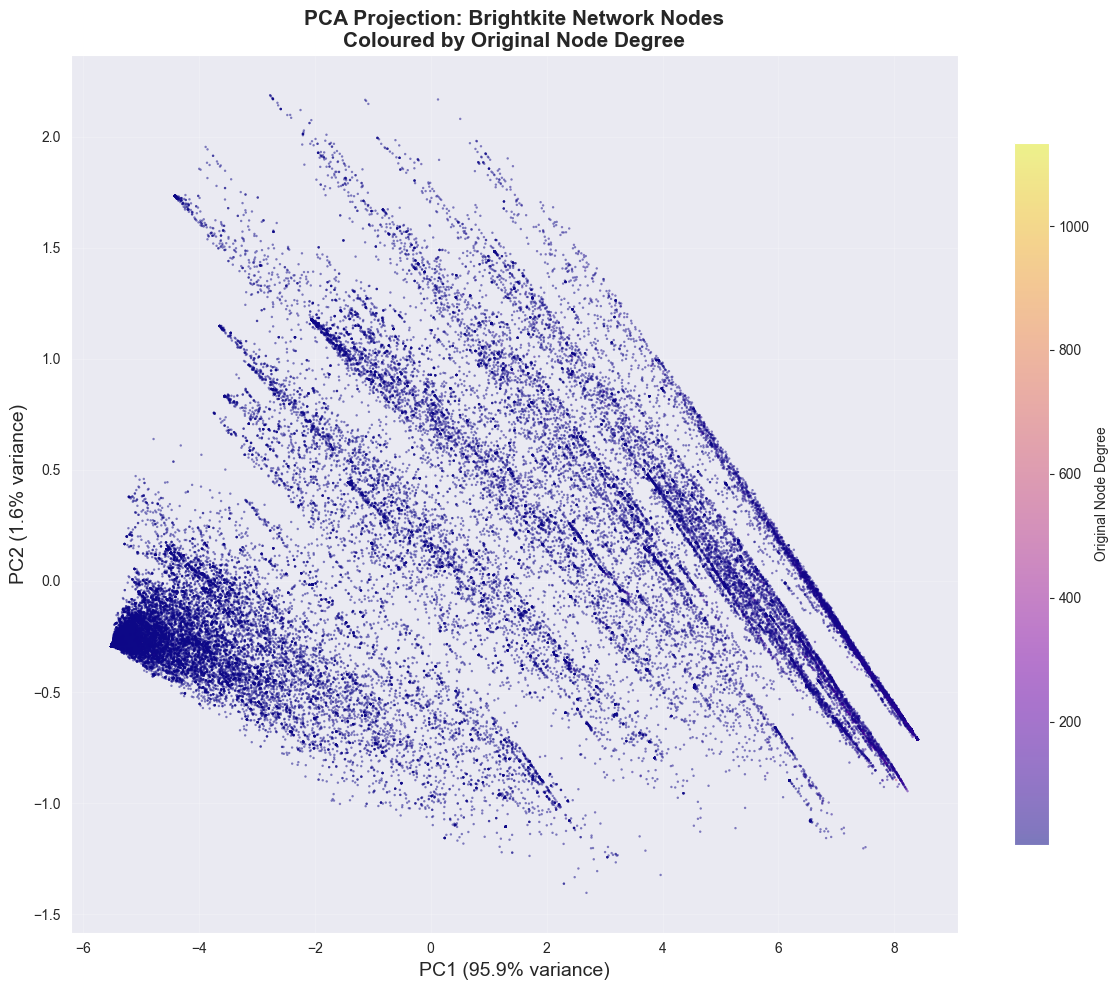

PC1 captures 95.9% variance
PC1+PC2 captures 97.5% variance


In [21]:
# 2D PCA projection scatter plot (PC1 vs PC2)
fig, ax = plt.subplots(figsize=(12, 10))

original_degrees = np.array([G.degree(n) for n in all_nodes])

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=original_degrees,
                     cmap='plasma', s=3, alpha=0.5, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='Original Node Degree', shrink=0.8)

ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)', fontsize=14)
ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)', fontsize=14)
ax.set_title('PCA Projection: Brightkite Network Nodes\n'
             'Coloured by Original Node Degree',
             fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f'PC1 captures {explained_var[0]*100:.1f}% variance')
print(f'PC1+PC2 captures {cumulative_var[1]*100:.1f}% variance')

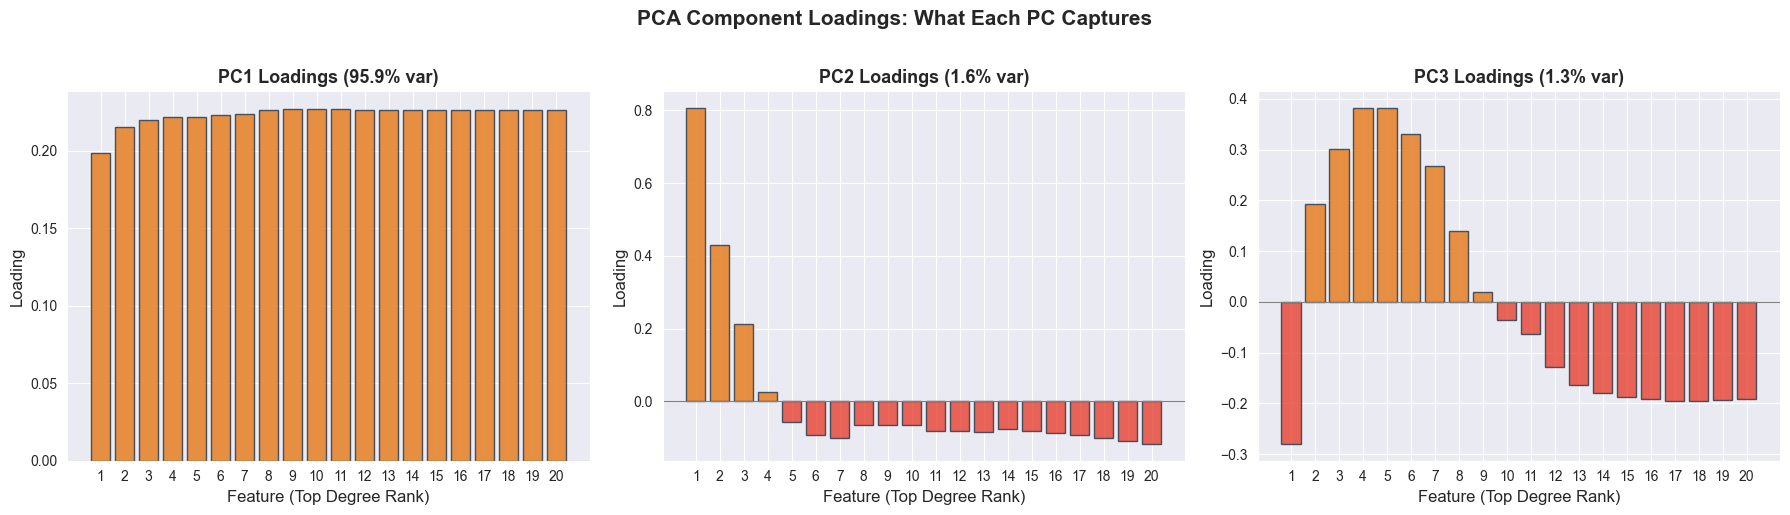

In [22]:
# PCA Loadings: What do the PCs represent?
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx in range(3):
    loadings = pca.components_[idx]
    colors_l = ['#e74c3c' if l < 0 else '#e67e22' for l in loadings]
    axes[idx].bar(range(1, 21), loadings, color=colors_l,
                  edgecolor='#2c3e50', alpha=0.85)
    axes[idx].set_xlabel('Feature (Top Degree Rank)', fontsize=12)
    axes[idx].set_ylabel('Loading', fontsize=12)
    axes[idx].set_title(f'PC{idx+1} Loadings '
                        f'({explained_var[idx]*100:.1f}% var)',
                        fontsize=13, fontweight='bold')
    axes[idx].set_xticks(range(1, 21))
    axes[idx].axhline(y=0, color='gray', linewidth=0.8)

plt.suptitle('PCA Component Loadings: What Each PC Captures',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Comparison with Experiment 1 (Facebook MUSAE)

In [23]:
print('=' * 70)
print('  COMPARISON: EXPERIMENT 1 (Facebook) vs EXPERIMENT 2 (Brightkite)')
print('=' * 70)
print(f'''
                          Facebook MUSAE     Brightkite (SNAP)
                          ---------------    -----------------
  Nodes:                  22,470             {num_nodes:,}
  Edges:                  171,002            {num_edges:,}
  Avg Degree:             15.22              {2*num_edges/num_nodes:.2f}
  Clustering:             0.6055             0.1723
  Diameter:               ~8                 16
  K used:                 K=2                K={K}
  Nbhd size range:        3 - 5,917          {min(neighbourhood_sizes)} - {max(neighbourhood_sizes)}
  Mean nbhd size:         ~2,500             {np.mean(neighbourhood_sizes):.0f}
  Feature matrix:         22,470 x 20        {len(feature_matrix)} x 20

  PCA RESULTS:
  60% variance:           1 PC               {results[0.60]} PCs
  80% variance:           1 PC               {results[0.80]} PCs
  90% variance:           1 PC               {results[0.90]} PCs
  PC1 explains:           98.5%              {explained_var[0]*100:.1f}%
  PC1+PC2 explains:       99.3%              {cumulative_var[1]*100:.1f}%
''')
print('=' * 70)

  COMPARISON: EXPERIMENT 1 (Facebook) vs EXPERIMENT 2 (Brightkite)

                          Facebook MUSAE     Brightkite (SNAP)
                          ---------------    -----------------
  Nodes:                  22,470             56,739
  Edges:                  171,002            212,945
  Avg Degree:             15.22              7.51
  Clustering:             0.6055             0.1723
  Diameter:               ~8                 16
  K used:                 K=2                K=3
  Nbhd size range:        3 - 5,917          4 - 44694
  Mean nbhd size:         ~2,500             4511
  Feature matrix:         22,470 x 20        56739 x 20

  PCA RESULTS:
  60% variance:           1 PC               1 PCs
  80% variance:           1 PC               1 PCs
  90% variance:           1 PC               1 PCs
  PC1 explains:           98.5%              95.9%
  PC1+PC2 explains:       99.3%              97.5%



---
## Summary & Conclusions

In [27]:
print('=' * 65)
print('    FINAL SUMMARY: BRIGHTKITE BIG DATA ANALYSIS (EXPT 2)')
print('=' * 65)
print(f'''
DATASET:
  Source:             Brightkite (SNAP)
  Total Nodes (N):    {num_nodes:,}
  Total Edges:        {num_edges:,}
  Graph Type:         Undirected, Location-based Social Network

NEIGHBOURHOOD SUBGRAPHS:
  K-distance used:    K = {K}
  Reason for K={K}:      Brightkite has lower avg degree (7.35) and
                      larger diameter (16) than Facebook. K={K} gives
                      meaningful variation ({min(neighbourhood_sizes)} to {max(neighbourhood_sizes)} nodes)
                      without covering the entire graph.

FEATURE ENGINEERING:
  For each of {N:,} nodes:
    -> Extracted {K}-hop neighbourhood induced subgraph
    -> Computed degree of all nodes in the subgraph
    -> Picked top 20 degree values as the feature vector
  Final dataset shape: {df_features.shape[0]} x {df_features.shape[1]}

PCA RESULTS:
  60% variance captured by: {results[0.60]} PCs
  80% variance captured by: {results[0.80]} PCs
  90% variance captured by: {results[0.90]} PCs

  PC1 alone explains:       {explained_var[0]*100:.1f}%
  PC1 + PC2 explains:       {cumulative_var[1]*100:.1f}%
''')
print('=' * 65)

    FINAL SUMMARY: BRIGHTKITE BIG DATA ANALYSIS (EXPT 2)

DATASET:
  Source:             Brightkite (SNAP)
  Total Nodes (N):    56,739
  Total Edges:        212,945
  Graph Type:         Undirected, Location-based Social Network

NEIGHBOURHOOD SUBGRAPHS:
  K-distance used:    K = 3
  Reason for K=3:      Brightkite has lower avg degree (7.35) and
                      larger diameter (16) than Facebook. K=3 gives
                      meaningful variation (4 to 44694 nodes)
                      without covering the entire graph.

FEATURE ENGINEERING:
  For each of 56,739 nodes:
    -> Extracted 3-hop neighbourhood induced subgraph
    -> Computed degree of all nodes in the subgraph
    -> Picked top 20 degree values as the feature vector
  Final dataset shape: 56739 x 20

PCA RESULTS:
  60% variance captured by: 1 PCs
  80% variance captured by: 1 PCs
  90% variance captured by: 1 PCs

  PC1 alone explains:       95.9%
  PC1 + PC2 explains:       97.5%

